# Euclidean VAE

In [1]:
import os
import sys

mvae_dir = os.path.split(os.getcwd())[0]
if mvae_dir not in sys.path:
    sys.path.append(mvae_dir)

In [2]:
%pwd
%load_ext autoreload
%autoreload 2

### Imports

In [3]:
import torch
import numpy as np
import torch.optim as optim

import lib.dataloaders as dataloaders
import lib.models as models
import lib.trainer as trainer
import lib.utils as utils
import lib.models.utils.save_load_models as modelutils



### Set up and initialize data loader

In [20]:
# Set random seed for reproducibility
torch.manual_seed(42)
np.random.seed(42)

### Dataloader

In [21]:
batch_size = 64

dataloader = dataloaders.load_fashion_mnist(batch_size)
train_loader, test_loader = dataloader

### Model

In [22]:
data_dim = 784
latent_dim = 8
sftbeta = 1
device = "cpu"
encoder_width = 128
encoder_depth = 1
decoder_width = 128
decoder_depth = 1

model_config = {'data_dim': data_dim, 'latent_dim': latent_dim, 'sftbeta': sftbeta, 'device': device,
                'encoder_width': encoder_width, 'encoder_depth': encoder_depth, 'decoder_width': decoder_width,
                'decoder_depth': decoder_depth}

euclidean_model = models.EuclideanVAE(model_config)

### Optimizer

In [23]:
learning_rate = 0.001

euclidean_optimizer = optim.Adam(euclidean_model.parameters(), lr=learning_rate)

### Train and evaluate model

In [24]:
num_epochs = 1
log_interval = 100
device = "cpu"
recon_loss = "MSE"

trainer_config = {'num_epochs': num_epochs, 'log_interval': log_interval, 'recon_loss': recon_loss, 'device': device}

euclidean_history = trainer.MVAETrainer(euclidean_model, dataloader, euclidean_optimizer, trainer_config).train()

Trainer successfully initialized.
Training the gaussianVAE model.
Starting epoch 1/1
Epoch [1/1], Step [100/938], Loss: 3255.1372
Epoch [1/1], Step [200/938], Loss: 2479.0039
Epoch [1/1], Step [300/938], Loss: 2880.4880
Epoch [1/1], Step [400/938], Loss: 2315.4514
Epoch [1/1], Step [500/938], Loss: 2197.7461
Epoch [1/1], Step [600/938], Loss: 2187.0300
Epoch [1/1], Step [700/938], Loss: 1858.7190
Epoch [1/1], Step [800/938], Loss: 2016.1578
Epoch [1/1], Step [900/938], Loss: 1872.0323
Epoch 1/1, Train Loss: 38.5722, Test Loss: 29.6129
--------------------------------------------------


### Plot history

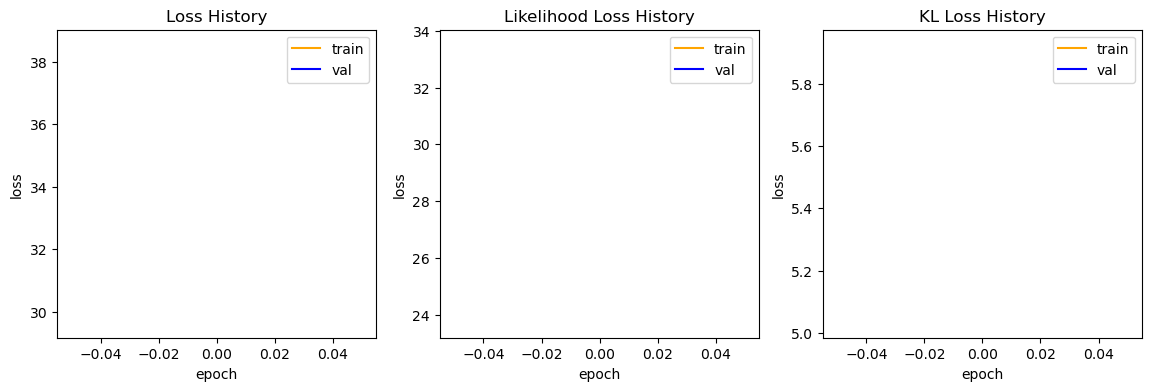

In [25]:
utils.show_training_history(euclidean_history)

### Save trained models

In [26]:
#modelutils.save_model(euclidean_model, model_config, "8dimLS")

#### Load pretrained models

In [27]:
#model = modelutils.load_model("gaussian_test1740071726")
#model = euclidean_model

### Visualizing the latent space

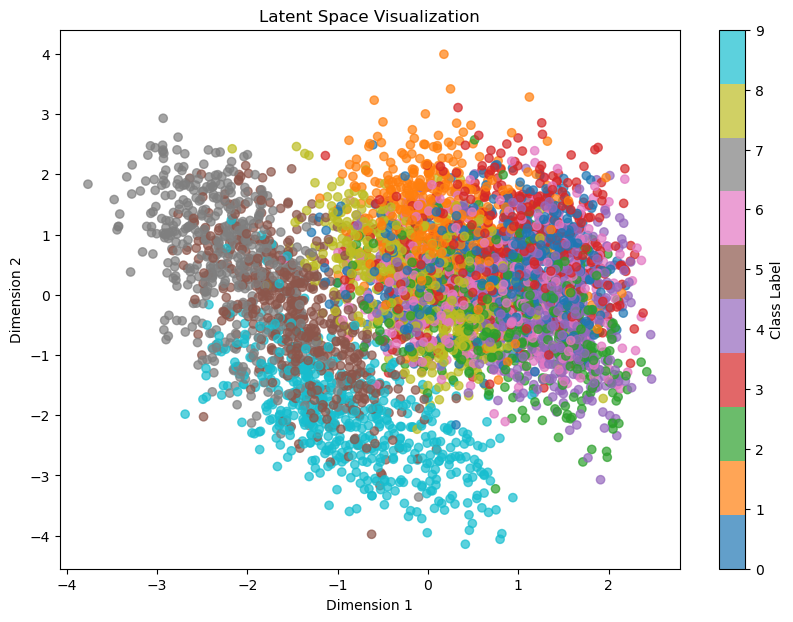

In [28]:
utils.plot_euclidean_latent_space(euclidean_model, test_loader, n_samples=5000)

#### Visualize reconstructed mnist images

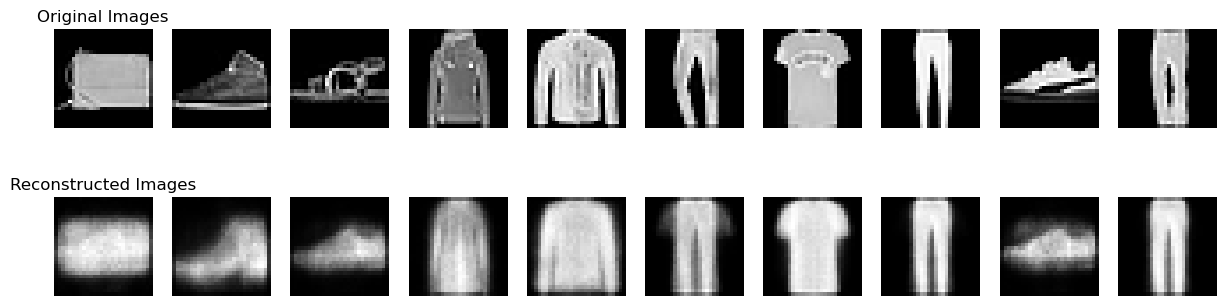

In [29]:
utils.show_recon_mnist(euclidean_model, test_loader)